Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you :
- Fill in your name
- Fill any place that says `YOUR CODE HERE` (you will be graded based on this code, any extra cells you code will not be graded)
- Delete  `NotImplementedError()` exception once you have completed your implementation

In [49]:
NAME = "NGUYEN THI THU TRANG"

# **Problem 1: Tree Traversal Algorithms Implementation (3)**

Given class Node and Queue, implement a BinaryTree class which include following methods:

- `add_left(self, parent, child)`: Method to add left child
- `add_right(self, parent, child)`: Method to add right child
- `preorder(self, root)`: print the tree using preorder traversal
- `postorder(self, root)`: print the tree using postorder traversal
- `breadthfirst(self, root)`: print the tree using breadth - first traversal
- `inorder(self, root)`: print the tree using inorder traversal

In [50]:
class Node:
    def __init__(self, value, left = None, right = None):
        self.value = value
        self.left = left
        self.right = right

    def __repr__(self):
        return str(self.value)

In [51]:
class Queue:
    def __init__(self):
        self.queue = []
        self.size = 0

    def enqueue(self, x):
        self.queue.append(x)
        self.size += 1

    def __len__(self):
        return self.size

    def dequeue(self):
        if self.size == 0:
            raise Exception("Empty")
        self.size -= 1
        return self.queue.pop(0)

    def empty(self):
        return self.size == 0

In [52]:
class BinaryTree:
    def __init__(self, root):
        self.root = root
        self.pre, self.post, self.in_, self.bf = [], [], [], []

    def add_left(self, parent, child):
        if not isinstance(parent, Node) and not isinstance(child, Node):
            raise ValueError("Invalid value")
        else:
            parent.left = child

    def add_right(self, parent, child):
        if not isinstance(parent, Node) and not isinstance(child, Node):
            raise ValueError("Invalid value")
        else:
            parent.right = child

    def __str__(self):
        def update(root, r, c):
            if root is None:
                return
            ans[r][c] = str(root.value)
            update(root.left, r + 1, c - 2 ** (height - 1  - r - 1))
            update(root.right, r + 1, c + 2 ** (height - 1 - r - 1))

        height, width = self.height(self.root) + 1, 2 ** (self.height(self.root) + 1) - 1
        ans = [[" "] * width for _ in range(height)]
        update(self.root, 0, (width - 1) // 2)
        return '\n'.join([' '.join(row) for row in ans])

    def height(self, node):
        if node is None:
            return -1
        else:
            return max(self.height(node.left), self.height(node.right)) + 1

    def preorder(self, node: Node):
        if node is None:
            return
        self.pre.append(node.value)
        self.preorder(node.left)
        self.preorder(node.right)
        return self.pre
        
    def postorder(self, node: Node):
        if node is None:
            return
        self.postorder(node.left)
        self.postorder(node.right)
        self.post.append(node.value)
        return self.post

    def inorder(self, node: Node):
        if node is None:
            return
        self.inorder(node.left)
        self.in_.append(node.value)
        self.inorder(node.right)
        return self.in_

    def breadfirst(self, node: Node, q = Queue()):
        if node is None:
            return
        q.enqueue(node)
        while not q.empty():
            node = q.dequeue()
            if node.left:
                q.enqueue(node.left)
            if node.right:
                q.enqueue(node.right)
            self.bf.append(node.value)
        return self.bf

In [53]:
a, b, c, d, e, f, g, h, i, j, k, l, m, n, o, p, q, r, s, t, u = Node(1),  Node(2),  Node(3),  Node(4),  Node(5),  Node(6), Node(7), Node(8), Node(9), Node(10), Node(11), Node(12), Node(13),  Node(14),  Node(15),  Node(16), Node(17), Node(18),  Node(19), Node(20), Node(21)
bt = BinaryTree(a)
bt.add_left(a,b)
bt.add_right(a,c)
bt.add_left(b,d)
bt.add_right(b,e)
bt.add_left(c,f)
bt.add_right(c,g)
bt.add_left(b,d)
bt.add_right(b,e)
bt.add_left(d,h)
bt.add_right(d,i)
bt.add_left(e,j)
bt.add_right(e,k)
bt.add_left(f,l)
bt.add_right(f,m)
bt.add_left(g,n)
bt.add_right(g,o)
bt.add_left(k,p)
bt.add_right(k,q)
bt.add_left(n,r)
bt.add_right(n,s)
bt.add_left(q,t)
bt.add_left(s,u)

In [54]:
assert bt.postorder(a) == [8, 9, 4, 10, 16, 20, 17, 11, 5, 2, 12, 13, 6, 18, 21, 19, 14, 15, 7, 3, 1]
assert bt.preorder(a) == [1, 2, 4, 8, 9, 5, 10, 11, 16, 17, 20, 3, 6, 12, 13, 7, 14, 18, 19, 21, 15]
assert bt.inorder(a) == [8, 4, 9, 2, 10, 5, 16, 11, 20, 17, 1, 12, 6, 13, 3, 18, 14, 21, 19, 7, 15]
assert bt.breadfirst(a) == [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]

# **Problem 2: Sum of lonely nodes (3)**

In a binary tree, a lonely node is a node that is the only child of its parent node. The root of the tree is not lonely because it does not have a parent node.

Given the root of a binary tree, return sum of the values of all lonely nodes in the tree.

In [55]:
def lonely_nodes(node: Node):
    def dfs(node):
        if not node or (not node.left and not node.right):
            return
        if node.left and not node.right:
            lonely.append(node.left.value)
        if node.right and not node.left:
            lonely.append(node.right.value)
        
        dfs(node.left)
        dfs(node.right)
    
    lonely = []
    dfs(node)
    return sum(lonely)

In [56]:
t11, t12, t13, t14 = Node(1), Node(2), Node(3), Node(4)
t21, t22, t23, t24, t25, t26, t27 = Node(7), Node(1), Node(4), Node(6),Node(5), Node(3), Node(2)
t31, t32, t33, t34, t35, t36, t37, t38, t39 = Node(11), Node(99), Node(88), Node(77), Node(66), Node(55), Node(44), Node(33), Node(22)

test1 = BinaryTree(t11)
test1.add_left(t11,t12)
test1.add_right(t11,t13)
test1.add_right(t12,t14)

test2 = BinaryTree(t21)
test2.add_left(t21,t22)
test2.add_right(t21,t23)
test2.add_left(t22,t24)
test2.add_left(t23,t25)
test2.add_right(t23,t26)
test2.add_right(t26,t27)

test3 = BinaryTree(t31)
test3.add_left(t31,t32)
test3.add_right(t31,t33)
test3.add_left(t32,t34)
test3.add_right(t33,t35)
test3.add_left(t34,t36)
test3.add_right(t35,t37)
test3.add_left(t36,t38)
test3.add_right(t37,t39)

In [57]:
print("Tree for test case 1")
print(test1)
print("Tree for test case 2")
print(test2)
print("Tree for test case 3")
print(test3)

Tree for test case 1
      1      
  2       3  
    4        
Tree for test case 2
              7              
      1               4      
  6               5       3  
                            2
Tree for test case 3
                              11                              
              99                               88              
      77                                               66      
  55                                                       44  
33                                                           22


In [58]:
assert lonely_nodes(t11) == 4
assert lonely_nodes(t21) == 8
assert lonely_nodes(t31) == 297

# **Problem 3: Find the Diagonal Sum of a Binary Tree (2)**
Given a binary tree, calculate the sum of all nodes for each diagonal having negative slope \. Assume that the left and right child of a node makes a 45–degree angle with the parent.

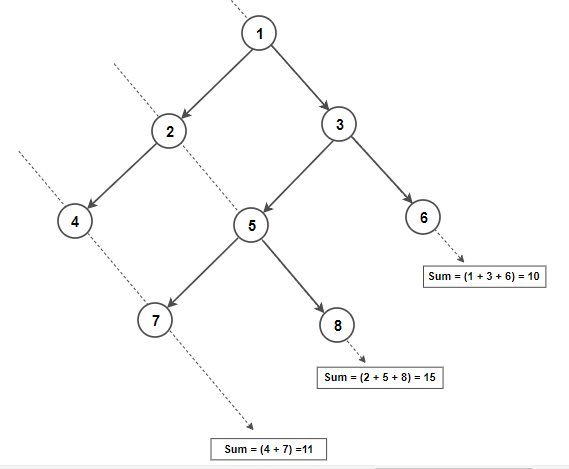

NOTE: You don't need to return anything, simply print the output and try to make it similar to the output in the given image

In [59]:
def diagonalsum(node: Node):
    if not node:
        return []
    
    result = []
    q = Queue()
    q.enqueue(node)

    while q:
        size = len(q)
        total = 0

        for _ in range(size):
            node = q.dequeue()
            while node:
                total += node.value

                if node.left:
                    q.enqueue(node.left)
                node = node.right

        result.append(total)

    return result
    

In [60]:
n1, n2, n3, n4, n5, n6, n7, n8 = Node(1), Node(2), Node(3), Node(4), Node(5), Node(6), Node(7), Node(8)
tr = BinaryTree(n1)
tr.add_left(n1,n2)
tr.add_right(n1,n3)
tr.add_left(n2,n4)
tr.add_left(n3,n5)
tr.add_right(n3,n6)
tr.add_left(n5,n7)
tr.add_right(n5,n8)

In [61]:
print(diagonalsum(n1))

[10, 15, 11]


In [62]:
# DO NOT DELETE THIS CELL

# **Problem 4: Employee Importance! (2)**

Your company has encountered a cut-off, and you need to decide which employee should be fired. You noticed that for each employee, if they are fired, their subordinates would follow them. Therefore, for an optimized cut-off, you need to evaluate the importance of each employee to make the correct decision.

You have a data structure of employee information, including the employee's unique ID, importance value, and direct subordinates' IDs.

You are given an array of employees employees where:

1. employees[i].id is the ID of the ith employee.
2. employees[i].importance is the importance value of the ith employee.
3. employees[i].subordinates is a list of the IDs of the direct subordinates of the ith employee.

Given an integer id that represents an employee's ID, return the total importance value of this employee and all their direct and indirect subordinates.

Example:
```
Input: employees = [[1,5,[2,3]],[2,3,[]],[3,3,[]]], id = 1 where each element in employees is an Employee object.
Output: 11

Explanation: Employee 1 has an importance value of 5 and has two direct subordinates: employee 2 and employee 3.
They both have an importance value of 3.
Thus, the total importance value of employee 1 is 5 + 3 + 3 = 11.
```
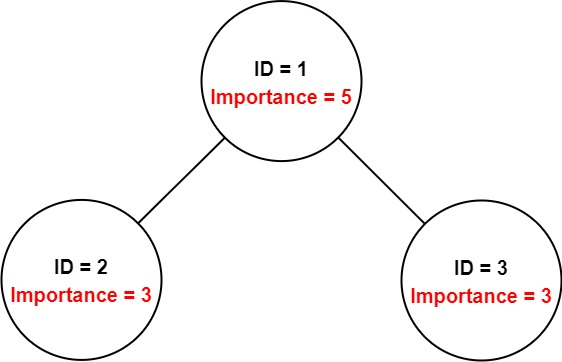

In [63]:
class Employee:
    def __init__(self, id: int, importance: int, subordinates: list[int]):
        self.id = id
        self.importance = importance
        self.subordinates = subordinates

In [64]:
def getImportance(employees: list[Employee], id: int) -> int:
    emps = {}
    for emp in employees:
        emps[emp.id] = emp
    
    def dfs(emp):
        imp = emps[emp].importance
        for s in emps[emp].subordinates:
            imp += dfs(s)
        
        return imp
    
    return dfs(id)

In [65]:
boss = Employee(1, 5, [2, 3])
emp1 = Employee(2,3,[])
emp2 = Employee(3,3,[])
employees = [boss, emp1, emp2]

assert getImportance(employees, 1) == 11

In [66]:
boss = Employee(1, 10, [])
employees = [boss]

assert getImportance(employees, 1) == 10

In [67]:
# DO NOT DELETE THIS CELL

In [68]:
# DO NOT DELETE THIS CELL